In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score,
                              confusion_matrix, f1_score,
                              classification_report)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
DATASET_PATH = Path(r"C:\Users\jessi\OneDrive\Desktop\aiims2")

df = pd.read_csv(DATASET_PATH / 'features_combined_ultrasam.csv')

# Binary classification: benign vs malignant only
df = df[df['label'].isin(['benign', 'malignant'])].copy()
df['target'] = (df['label'] == 'malignant').astype(int)  # 1=malignant, 0=benign

print(f"Total cases: {len(df)}")
print(df['label'].value_counts())

Total cases: 647
label
benign       437
malignant    210
Name: count, dtype: int64


In [3]:


# Drop non-feature columns
DROP_COLS = ['case_id', 'label', 'target']
feature_cols = [c for c in df.columns if c not in DROP_COLS]

X = df[feature_cols].fillna(0).values
y = df['target'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Positive (malignant): {y.sum()} | Negative (benign): {(1-y).sum()}")

# Train/test split — stratified so both classes are balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — important for SVM, LR, MLP
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Feature matrix shape: (647, 1156)
Positive (malignant): 210 | Negative (benign): 437
Train size: 517 | Test size: 130


In [4]:
classifiers = {
    'Random Forest'     : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost'           : XGBClassifier(n_estimators=200, random_state=42,
                                         use_label_encoder=False,
                                         eval_metric='logloss', verbosity=0),
    'LightGBM'          : LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM'               : SVC(kernel='rbf', probability=True, random_state=42),
    'MLP'               : MLPClassifier(hidden_layer_sizes=(256, 128),
                                        max_iter=500, random_state=42),
}

In [5]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_prob  = model.predict_proba(X_te)[:, 1]

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        'auc'        : round(roc_auc_score(y_te, y_prob), 4),
        'accuracy'   : round(accuracy_score(y_te, y_pred), 4),
        'sensitivity': round(tp / (tp + fn) if (tp+fn) > 0 else 0, 4),
        'specificity': round(tn / (tn + fp) if (tn+fp) > 0 else 0, 4),
        'f1'         : round(f1_score(y_te, y_pred), 4),
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
    }

results = {}
for name, clf in classifiers.items():
    print(f"Training {name}...")
    results[name] = evaluate(clf, X_train, y_train, X_test, y_test)

print("\nDone!")

Training Random Forest...
Training XGBoost...
Training LightGBM...


C:\Users\jessi\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\jessi\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Logistic Regression...
Training SVM...
Training MLP...

Done!


In [6]:
df_results = pd.DataFrame(results).T
df_results = df_results.sort_values('auc', ascending=False)
print(df_results[['auc', 'accuracy', 'sensitivity', 'specificity', 'f1']])

                        auc  accuracy  sensitivity  specificity      f1
MLP                  0.9811    0.9385       0.9524       0.9318  0.9091
Logistic Regression  0.9589    0.9231       0.8571       0.9545  0.8780
SVM                  0.9583    0.8846       0.7857       0.9318  0.8148
LightGBM             0.9529    0.8923       0.8095       0.9318  0.8293
XGBoost              0.9521    0.8923       0.8333       0.9205  0.8333
Random Forest        0.9382    0.8615       0.7143       0.9318  0.7692


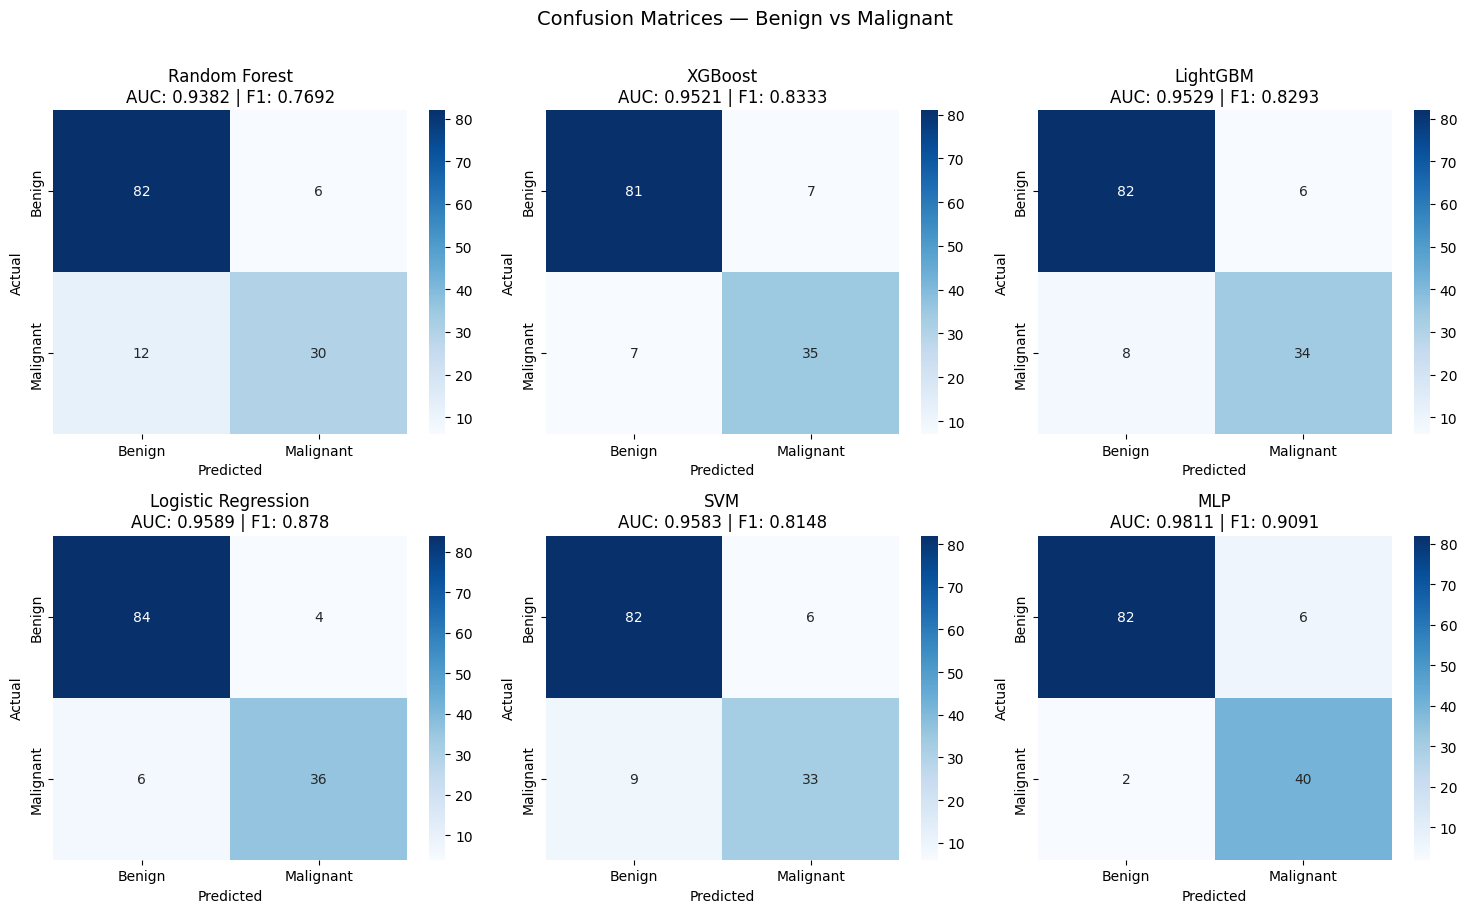

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = np.array([[res['tn'], res['fp']],
                   [res['fn'], res['tp']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    axes[i].set_title(f"{name}\nAUC: {res['auc']} | F1: {res['f1']}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Benign vs Malignant', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
df_results.to_csv(DATASET_PATH / 'results.csv')
print(f"Saved results.csv")
print(f"\nBest model: {df_results['auc'].idxmax()} "
      f"with AUC = {df_results['auc'].max()}")

Saved results.csv

Best model: MLP with AUC = 0.9811


In [9]:
# re-extract y_prob from the best model (Logistic Regression)
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

best_model = clone(classifiers['Logistic Regression'])
best_model.fit(X_train, y_train)
y_prob = best_model.predict_proba(X_test)[:, 1]

# ── 1. shuffled label test ──────────────────────────────────────
y_shuffled = y_test.copy()
np.random.shuffle(y_shuffled)
print('Real AUC:    ', round(roc_auc_score(y_test,    y_prob), 4))
print('Shuffled AUC:', round(roc_auc_score(y_shuffled, y_prob), 4))
print()

# ── 2. train vs test gap ────────────────────────────────────────
y_prob_train = best_model.predict_proba(X_train)[:, 1]
print('Train AUC:', round(roc_auc_score(y_train, y_prob_train), 4))
print('Test AUC: ', round(roc_auc_score(y_test,  y_prob), 4))
print()

# ── 3. cross-val stability ──────────────────────────────────────
from sklearn.model_selection import cross_val_score
scores = cross_val_score(clone(classifiers['Logistic Regression']),
                         X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print('CV folds:', np.round(scores, 4))
print('Mean:', round(scores.mean(), 4), ' Std:', round(scores.std(), 4))


Real AUC:     0.9589
Shuffled AUC: 0.5687

Train AUC: 1.0
Test AUC:  0.9589

CV folds: [0.9517 0.9538 0.9472 0.9784 0.9612]
Mean: 0.9584  Std: 0.0109


In [10]:
# fast version — use model coefficients directly (works for Logistic Regression)
imp = pd.Series(
    np.abs(best_model.coef_[0]),
    index=feature_cols
).sort_values(ascending=False)

print('Top 20 features driving AUC:')
print(imp.head(20))

Top 20 features driving AUC:
skewness_skin                0.586961
lbp_8_ring_15px              0.508055
lbp_6_ring_5px               0.489428
lbp_2_skin                   0.437346
lbp_3_skin                   0.410320
glcm_contrast_ring_5px       0.405475
whole_96                     0.402330
lbp_1_skin                   0.396922
glcm_energy_ring_5px         0.367740
std_intensity_ring_5px       0.367535
glcm_homogeneity_ring_5px    0.363242
lbp_7_ring_5px               0.355168
edge_density_background      0.352340
glcm_contrast_background     0.351805
glcm_homogeneity_tumor       0.349734
whole_170                    0.344480
lbp_5_ring_5px               0.339677
whole_244                    0.337597
posterior_125                0.336563
lbp_0_ring_15px              0.324799
dtype: float64


In [18]:
for name, X_subset in [('Texture only', X_texture),
                        ('Deep only',    X_deep),
                        ('Combined',     X_combined)]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_subset, y, test_size=0.2, random_state=42, stratify=y)
    sc   = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)
    m    = LogisticRegression(max_iter=1000, random_state=42, C=0.1)
    m.fit(X_tr, y_tr)
    auc  = roc_auc_score(y_te, m.predict_proba(X_te), multi_class='ovr', average='macro')
    cv   = cross_val_score(
               LogisticRegression(max_iter=1000, random_state=42, C=0.1),
               X_tr, y_tr, cv=5, scoring='roc_auc_ovr_weighted').mean()
    acc  = m.score(X_te, y_te)
    print(f'{name:20s}  Test AUC: {auc:.4f}  CV AUC: {cv:.4f}  Acc: {acc:.4f}')

print(f'\nClasses: {le.classes_}')  # 0=benign, 1=malignant, 2=normal

Texture only          Test AUC: 0.9480  CV AUC: 0.9569  Acc: 0.8654
Deep only             Test AUC: 0.9830  CV AUC: 0.9675  Acc: 0.9487
Combined              Test AUC: 0.9821  CV AUC: 0.9748  Acc: 0.9487

Classes: ['benign' 'malignant' 'normal']


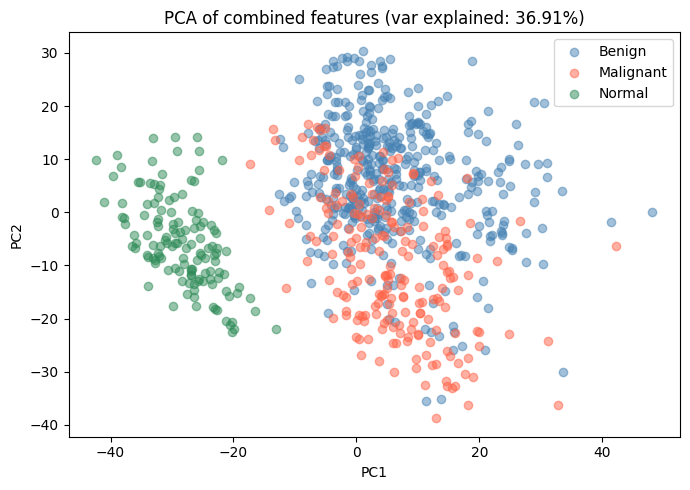

In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Choose which to visualize: X_texture, X_deep, or X_combined
X_viz = X_combined  # change this to X_texture or X_deep if you want

pca  = PCA(n_components=2)
X_2d = pca.fit_transform(StandardScaler().fit_transform(X_viz))

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[y==0, 0], X_2d[y==0, 1], alpha=0.5, label='Benign',    color='steelblue')
plt.scatter(X_2d[y==1, 0], X_2d[y==1, 1], alpha=0.5, label='Malignant', color='tomato')
plt.scatter(X_2d[y==2, 0], X_2d[y==2, 1], alpha=0.5, label='Normal',    color='seagreen')
plt.legend()
plt.title(f'PCA of combined features (var explained: {pca.explained_variance_ratio_.sum():.2%})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

In [33]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

DATASET_PATH = Path(r"C:\Users\jessi\OneDrive\Desktop\aiims2")
df = pd.read_csv(DATASET_PATH / 'features_combined_ultrasam.csv')

# Rebuild everything cleanly from scratch
le = LabelEncoder()
y  = le.fit_transform(df['label'])  # all 780 rows

meta_cols     = ['case_id', 'label']
CROP_NAMES    = ['tumor', 'perilesion', 'posterior', 'whole']
deep_prefixes = tuple(f'{c}_' for c in CROP_NAMES)

deep_cols    = [c for c in df.columns if c.startswith(deep_prefixes)]
texture_cols = [c for c in df.columns if c not in meta_cols and c not in deep_cols]

X_texture  = df[texture_cols].fillna(0).values
X_deep     = df[deep_cols].fillna(0).values
X_combined = np.hstack([X_texture, X_deep])

print(f'X_texture : {X_texture.shape}')
print(f'X_deep    : {X_deep.shape}')
print(f'X_combined: {X_combined.shape}')
print(f'y         : {y.shape}')
print(f'Classes   : {le.classes_}')  # should be 780 for all

X_texture : (780, 132)
X_deep    : (780, 1024)
X_combined: (780, 1156)
y         : (780,)
Classes   : ['benign' 'malignant' 'normal']


In [34]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    'Texture only':  (X_texture,  Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(C=0.1, max_iter=1000))])),
    'Deep only':     (X_deep,     Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=50)), ('clf', LogisticRegression(C=0.1, max_iter=1000))])),
    'Combined':      (X_combined, Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=100)), ('clf', LogisticRegression(C=0.1, max_iter=1000))])),
}

for name, (X_sub, pipe) in pipelines.items():
    scores = cross_val_score(pipe, X_sub, y, cv=cv, scoring='roc_auc_ovr_weighted')
    print(f'{name:20s}  AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Texture only          AUC: 0.9546 ± 0.0146
Deep only             AUC: 0.9668 ± 0.0062
Combined              AUC: 0.9752 ± 0.0055


In [35]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

pipelines2 = {
    'RF Combined':  (X_combined, Pipeline([('sc', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, random_state=42))])),
    'SVM Combined': (X_combined, Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=100)), ('clf', SVC(probability=True, C=1.0))])),
}

for name, (X_sub, pipe) in pipelines2.items():
    scores = cross_val_score(pipe, X_sub, y, cv=cv, scoring='roc_auc_ovr_weighted')
    print(f'{name:20s}  AUC: {scores.mean():.4f} ± {scores.std():.4f}')

RF Combined           AUC: 0.9749 ± 0.0088
SVM Combined          AUC: 0.9803 ± 0.0068


In [22]:
# check how many unique patients / cases
print('Total cases:', len(df))
print('Malignant:  ', (y==1).sum())
print('Benign:     ', (y==0).sum())
print()
# check if case_ids look like a known dataset
print(df['case_id'].head(10))

Total cases: 780
Malignant:   210
Benign:      437

0      benign (1)
1     benign (10)
2    benign (100)
3    benign (101)
4    benign (102)
5    benign (103)
6    benign (104)
7    benign (105)
8    benign (106)
9    benign (107)
Name: case_id, dtype: object


In [23]:
print(df.columns.tolist()[:30])

['case_id', 'label', 'edge_density_background', 'edge_density_posterior', 'edge_density_ring_15px', 'edge_density_ring_5px', 'edge_density_skin', 'edge_density_tumor', 'entropy_background', 'entropy_posterior', 'entropy_ring_15px', 'entropy_ring_5px', 'entropy_skin', 'entropy_tumor', 'glcm_contrast_background', 'glcm_contrast_posterior', 'glcm_contrast_ring_15px', 'glcm_contrast_ring_5px', 'glcm_contrast_skin', 'glcm_contrast_tumor', 'glcm_correlation_background', 'glcm_correlation_posterior', 'glcm_correlation_ring_15px', 'glcm_correlation_ring_5px', 'glcm_correlation_skin', 'glcm_correlation_tumor', 'glcm_energy_background', 'glcm_energy_posterior', 'glcm_energy_ring_15px', 'glcm_energy_ring_5px']


In [24]:
deep_df = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_deep.csv')
print(deep_df.shape)
print(deep_df.columns.tolist()[:10])
print(deep_df.head(2))

(780, 3074)
['case_id', 'label', 'tumor_0', 'tumor_1', 'tumor_2', 'tumor_3', 'tumor_4', 'tumor_5', 'tumor_6', 'tumor_7']
       case_id   label   tumor_0   tumor_1   tumor_2   tumor_3   tumor_4  \
0   benign (1)  benign -0.140227  0.199341  0.014288 -0.093048  0.300193   
1  benign (10)  benign -0.004000  0.183299 -0.220773  0.085275  0.018301   

    tumor_5   tumor_6   tumor_7  ...  whole_758  whole_759  whole_760  \
0 -0.061440 -0.245403  0.049486  ...  -0.056358  -0.106251  -0.021558   
1 -0.010775 -0.196513 -0.021403  ...  -0.161345   0.008025   0.132144   

   whole_761  whole_762  whole_763  whole_764  whole_765  whole_766  whole_767  
0   0.098186   0.071740   0.034187   0.023795  -0.224141   0.102715  -0.009094  
1   0.061322  -0.013692   0.085919  -0.138765  -0.025004   0.123716   0.132169  

[2 rows x 3074 columns]


In [25]:
texture_df = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_texture.csv')
deep_df    = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_deep.csv')

# drop normal from deep too
deep_df = deep_df[deep_df['label'].isin(['benign', 'malignant'])].copy()

print('Texture rows:', len(texture_df))
print('Deep rows:   ', len(deep_df))

# merge on case_id
combined = pd.merge(texture_df, deep_df.drop(columns=['label']), on='case_id', how='inner')

print('Combined rows:   ', len(combined))
print('Combined columns:', combined.shape[1])

# save
combined.to_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_combined.csv', index=False)
print('Saved features_combined.csv')

Texture rows: 780
Deep rows:    647
Combined rows:    647
Combined columns: 3206
Saved features_combined.csv


In [26]:
texture_df = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_texture.csv')
print(texture_df.shape)
print(texture_df.head(5)[['case_id', 'label']]) 
print(texture_df['case_id'].value_counts().head(10))

(780, 134)
        case_id   label
0    benign (1)  benign
1   benign (10)  benign
2  benign (100)  benign
3  benign (101)  benign
4  benign (102)  benign
case_id
benign (1)      1
benign (10)     1
benign (100)    1
benign (101)    1
benign (102)    1
benign (103)    1
benign (104)    1
benign (105)    1
benign (106)    1
benign (107)    1
Name: count, dtype: int64


In [10]:
texture_df = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_texture.csv')
deep_df    = pd.read_csv(r'C:\Users\jessi\OneDrive\Desktop\aiims2\features_deep.csv')

# check what the region column is called
print(texture_df.columns.tolist())

['case_id', 'label', 'edge_density_background', 'edge_density_posterior', 'edge_density_ring_15px', 'edge_density_ring_5px', 'edge_density_skin', 'edge_density_tumor', 'entropy_background', 'entropy_posterior', 'entropy_ring_15px', 'entropy_ring_5px', 'entropy_skin', 'entropy_tumor', 'glcm_contrast_background', 'glcm_contrast_posterior', 'glcm_contrast_ring_15px', 'glcm_contrast_ring_5px', 'glcm_contrast_skin', 'glcm_contrast_tumor', 'glcm_correlation_background', 'glcm_correlation_posterior', 'glcm_correlation_ring_15px', 'glcm_correlation_ring_5px', 'glcm_correlation_skin', 'glcm_correlation_tumor', 'glcm_energy_background', 'glcm_energy_posterior', 'glcm_energy_ring_15px', 'glcm_energy_ring_5px', 'glcm_energy_skin', 'glcm_energy_tumor', 'glcm_homogeneity_background', 'glcm_homogeneity_posterior', 'glcm_homogeneity_ring_15px', 'glcm_homogeneity_ring_5px', 'glcm_homogeneity_skin', 'glcm_homogeneity_tumor', 'kurtosis_background', 'kurtosis_posterior', 'kurtosis_ring_15px', 'kurtosis_ri

In [29]:
# Everything you need is already in memory from the previous cells:
# X_texture  (780, 132)
# X_deep     (780, 1024)
# X_combined (780, 1156)
# y          (780,)  — 0=benign, 1=malignant, 2=normal

# Or reload from disk:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

DATASET_PATH = Path(r"C:\Users\jessi\OneDrive\Desktop\aiims2")
df = pd.read_csv(DATASET_PATH / 'features_combined_ultrasam.csv')

le = LabelEncoder()
y  = le.fit_transform(df['label'])

meta_cols    = ['case_id', 'label']
CROP_NAMES   = ['tumor', 'perilesion', 'posterior', 'whole']
deep_prefixes = tuple(f'{c}_' for c in CROP_NAMES)

deep_cols    = [c for c in df.columns if c.startswith(deep_prefixes)]
texture_cols = [c for c in df.columns if c not in meta_cols and c not in deep_cols]

X_texture  = df[texture_cols].fillna(0).values
X_deep     = df[deep_cols].fillna(0).values
X_combined = np.hstack([X_texture, X_deep])

print(f'Texture : {X_texture.shape}')
print(f'Deep    : {X_deep.shape}')
print(f'Combined: {X_combined.shape}')
print(f'Classes : {le.classes_}')

Texture : (780, 132)
Deep    : (780, 1024)
Combined: (780, 1156)
Classes : ['benign' 'malignant' 'normal']
